# 第三章：加密流量检测模型构建

本章把 CIC-IDS2017 原始流量特征处理成多通道张量，再用 MindSpore ResNet 完成加密恶意流量分类与结果评估，形成一条从原始 CSV 到模型评估的完整链路。

## 目录约定

- 原始流量 CSV 放在 `src/`。
- 预处理中间结果（`.npy`）、模型权重和评估结果统一写入 `answer/`。


## 一、使用说明

按顺序运行全部单元：先把 `src/` 中的 CIC-IDS2017 CSV 预处理成 `[N, 6, 4, 4]` 张量并保存到 `answer/`，再读回训练 ResNet。模型权重和评估结果写入 `answer/`。默认 `cloud_live` 构造均衡小样本训练集；完整训练可设置环境变量 `ONSITE_DEMO_PROFILE=full`。重点观察：`macro_f1`（少数攻击类识别质量）、`confusion_matrix`（三类误判结构）、`samples_per_second`（推理吞吐）。

## 二、导入依赖与运行环境配置

本单元集中导入整条链路所需的库（NumPy/Pandas/Matplotlib、scikit-learn、MindSpore），解析课程目录以定位 `src/` 与 `answer/`，并完成两类配置：数据预处理参数（CSV 查找规则、保留标签、张量形状、划分比例）和训练运行参数（`ONSITE_DEMO_PROFILE` 控制的样本量与轮次、随机种子、Ascend/GPU/CPU 后端自动回退）。后续所有单元直接复用这里的变量。

In [2]:
import os
import io
import json
import time
import zipfile
import random
import sys
import warnings
from pathlib import Path

os.environ.setdefault("GLOG_v", "3")
os.environ.setdefault("PYTHONWARNINGS", "ignore")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

import mindspore as ms
import mindspore.dataset as ds
import mindspore.nn as nn
import mindspore.ops as ops

try:
    from IPython.display import display
except Exception:
    display = print

# 原始数据放在 src/；预处理中间结果、模型权重和评估结果统一写入 answer/。
CURRENT_DIR = Path.cwd().resolve()
# 目录结构已扁平化：notebook 与 src/、answer/、images/ 同级
chapter_candidates = [
    CURRENT_DIR,
    CURRENT_DIR / "01_threat_detect",
]
CHAPTER_DIR = next((path for path in chapter_candidates if (path / "src").is_dir()), None)
if CHAPTER_DIR is None:
    raise FileNotFoundError("未找到课程目录（需包含 src/），请从课程目录打开 Notebook。")
SRC_DIR = CHAPTER_DIR / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))
from plot_config import CLASS_COLORS, CHANNEL_COLORS, CHANNEL_LABELS, CHANNEL_ORDER, configure_plotting
FONT_PATH = configure_plotting(CHAPTER_DIR)
PROJECT_ROOT = CHAPTER_DIR
RAW_DIR = CHAPTER_DIR / "src"
SOURCE_DIR = RAW_DIR
IMAGE_DIR = CHAPTER_DIR / "images"
PROCESSED_DIR = CHAPTER_DIR / "answer"
DATA_DIR = PROCESSED_DIR
OUTPUT_DIR = PROCESSED_DIR
CKPT_DIR = PROCESSED_DIR
for path in (RAW_DIR, IMAGE_DIR, OUTPUT_DIR):
    path.mkdir(parents=True, exist_ok=True)

# ---- 数据预处理配置 ----
# 为空时自动查找本章 src/ 下的 CIC-ISCX/CIC-IDS CSV。
# 也可以手动指定，例如：CSV_FILES = ["Monday-WorkingHours.pcap_ISCX.csv", "Tuesday-WorkingHours.pcap_ISCX.csv"]
CSV_FILES = []
CSV_GLOBS = ["*WorkingHours*.csv", "*ISCX*.csv", "*CIC*.csv"]

# 默认只构造三分类任务。
KEEP_LABELS = ["BENIGN", "FTP-Patator", "SSH-Patator"]
LABEL_COL_CANDIDATES = ["Label", " Label", "label"]

VAL_RATIO = 0.15
TEST_RATIO = 0.15
RANDOM_STATE = 42

VARIANCE_THRESHOLD = 0.0
SKEW_THRESHOLD = 5.0
TARGET_H = 4
TARGET_W = 4
CHANNELS = 6
EXPECTED_INPUT_SIZE = (CHANNELS, TARGET_H, TARGET_W)

# 本地调试时可设置为整数限制每类读取行数；正式处理保持 None。
MAX_ROWS_PER_LABEL = None

# 默认不覆盖已有 processed 文件，避免误覆盖；确认重新生成时改为 True。
OVERWRITE = False

# ---- 训练运行配置 ----
RUN_PROFILE = os.environ.get("ONSITE_DEMO_PROFILE", "cloud_live").strip().lower()
PROFILE_SETTINGS = {
    "fast": {"train_per_class": 600, "eval_per_class": 160, "epochs": 3, "batch_size": 256, "base_channels": 24},
    "cloud_live": {"train_per_class": 2500, "eval_per_class": 450, "epochs": 8, "batch_size": 256, "base_channels": 32},
    "full": {"train_per_class": None, "eval_per_class": None, "epochs": 12, "batch_size": 512, "base_channels": 48},
}
if RUN_PROFILE not in PROFILE_SETTINGS:
    raise RuntimeError(f"Unsupported ONSITE_DEMO_PROFILE: {RUN_PROFILE}")
SETTINGS = PROFILE_SETTINGS[RUN_PROFILE]

SEED = 42
PREFERRED_DEVICE = os.environ.get("MS_DEVICE_TARGET", "Ascend")
DEVICE_ID = int(os.environ.get("DEVICE_ID", "0"))

# 固定随机种子，减少每次运行结果的波动。
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    ms.set_seed(seed)
    ds.config.set_seed(seed)

# 优先使用 Ascend；不可用时自动回退到 GPU 或 CPU。
def configure_mindspore_device(preferred="Ascend"):
    candidates = [preferred]
    for item in ["Ascend", "GPU", "CPU"]:
        if item not in candidates:
            candidates.append(item)
    errors = {}
    for device in candidates:
        try:
            ms.set_context(mode=ms.PYNATIVE_MODE, device_target=device)
            if device in {"Ascend", "GPU"}:
                try:
                    ms.set_context(device_id=DEVICE_ID)
                except Exception:
                    pass
            _ = ms.Tensor(np.ones((1,), dtype=np.float32))
            return device, errors
        except Exception as exc:
            errors[device] = repr(exc)
    raise RuntimeError(f"MindSpore 后端初始化失败：{errors}")

set_seed(SEED)
ACTUAL_DEVICE, DEVICE_ERRORS = configure_mindspore_device(PREFERRED_DEVICE)
argmax = ops.Argmax(axis=1, output_type=ms.int32)

print("=" * 70)
print("运行配置")
print("profile:", RUN_PROFILE, SETTINGS)
print("MindSpore 版本:", getattr(ms, "__version__", "unknown"))
print("当前后端:", ACTUAL_DEVICE)
if DEVICE_ERRORS:
    print("后端回退记录:", DEVICE_ERRORS)
print("原始 CSV 目录：", RAW_DIR)
print("processed / 输出目录：", OUTPUT_DIR)


运行配置
profile: cloud_live {'train_per_class': 2500, 'eval_per_class': 450, 'epochs': 8, 'batch_size': 256, 'base_channels': 32}
MindSpore 版本: 2.7.2
当前后端: Ascend
原始 CSV 目录： /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/src
processed / 输出目录： /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer


## 三、读取原始 CIC-ISCX CSV

从本章 `src/` 读取 CIC-IDS2017 的 Monday（正常流量）与 Tuesday（含 FTP/SSH 暴力破解）子集。`CSV_FILES` 为空时自动查找含 `WorkingHours`/`ISCX`/`CIC` 的 CSV，并跳过 `Ransomware.csv`。

In [3]:
# 数据集获取：若 src/ 下缺少 CIC-IDS2017 流量 CSV，则从指定地址下载。
# TODO: 在下方 DATASET_URLS 中填入实际下载地址（网盘直链或 HTTP 链接）后重运行本单元。
import urllib.request

DATASET_URLS = {
    "Monday-WorkingHours.pcap_ISCX.csv": "",   # TODO: 填入 Monday CSV 的下载地址
    "Tuesday-WorkingHours.pcap_ISCX.csv": "",  # TODO: 填入 Tuesday CSV 的下载地址
}


def _download_progress(block_num, block_size, total_size):
    downloaded = block_num * block_size
    if total_size > 0 and block_num % 100 == 0:
        pct = min(downloaded / total_size * 100, 100)
        print(f"  {downloaded / 1e6:.1f} / {total_size / 1e6:.1f} MB ({pct:.1f}%)")


def ensure_dataset(filename, url, download_dir):
    target = download_dir / filename
    if target.exists() and target.stat().st_size > 0:
        print(f"数据集已存在：{target}")
        return
    if not url:
        raise FileNotFoundError(
            f"未找到数据集 {filename}，且尚未配置下载地址。"
            f"请手动下载放入 {download_dir}，或在上方 DATASET_URLS 中填入下载地址后重运行本单元。"
        )
    print(f"正在下载 {filename} ← {url}")
    download_dir.mkdir(parents=True, exist_ok=True)
    urllib.request.urlretrieve(url, target, reporthook=_download_progress)
    print(f"下载完成：{target}")


for _name, _url in DATASET_URLS.items():
    ensure_dataset(_name, _url, SRC_DIR)


数据集已存在：/mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/src/Monday-WorkingHours.pcap_ISCX.csv
数据集已存在：/mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/src/Tuesday-WorkingHours.pcap_ISCX.csv


In [4]:
def find_csv_files(raw_dir: Path):
    if CSV_FILES:
        return [raw_dir / name for name in CSV_FILES]
    found = []
    seen = set()
    for pattern in CSV_GLOBS:
        for path in sorted(raw_dir.glob(pattern)):
            if path.name.lower() == "ransomware.csv":
                continue
            if path.suffix.lower() == ".csv" and path.resolve() not in seen:
                found.append(path)
                seen.add(path.resolve())
    return found


def normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df.columns = [str(col).strip() for col in df.columns]
    return df.loc[:, ~pd.Index(df.columns).duplicated()]


def find_label_col(columns):
    normalized = {str(col).strip().lower(): col for col in columns}
    for candidate in LABEL_COL_CANDIDATES:
        key = candidate.strip().lower()
        if key in normalized:
            return normalized[key]
    raise KeyError(f"未找到标签列，请检查 CSV 表头。当前前 10 列：{list(columns)[:10]}")


csv_paths = find_csv_files(RAW_DIR)
if not csv_paths:
    raise FileNotFoundError(f"未在 {RAW_DIR} 找到 CIC-ISCX/CIC-IDS CSV。请先把原始 CSV 放入本章 src/。")

missing = [str(path) for path in csv_paths if not path.exists()]
if missing:
    raise FileNotFoundError("以下 CSV 文件不存在：\n" + "\n".join(missing))

print("将读取的 CSV 文件：")
for path in csv_paths:
    print("  -", path.name)

frames = []
for path in csv_paths:
    part = pd.read_csv(path, low_memory=False)
    part = normalize_columns(part)
    part["__source_file"] = path.name
    frames.append(part)

df = pd.concat(frames, ignore_index=True, sort=False)
label_col = find_label_col(df.columns)
df[label_col] = df[label_col].astype(str).str.strip()

print("原始合并后形状：", df.shape)
raw_label_counts = df[label_col].value_counts()
print("筛选前标签分布：")
display(raw_label_counts.rename_axis("label").reset_index(name="count"))

if KEEP_LABELS is not None:
    before = len(df)
    df = df[df[label_col].isin(set(KEEP_LABELS))].copy()
    after = len(df)
    print(f"按 KEEP_LABELS 筛选：{before} -> {after} 行")
    if after == 0:
        raise ValueError(f"KEEP_LABELS={KEEP_LABELS} 筛选后没有剩余样本。")

task_label_counts = df[label_col].value_counts()

if MAX_ROWS_PER_LABEL is not None:
    df = (
        df.groupby(label_col, group_keys=False)
        .apply(lambda part: part.sample(n=min(len(part), int(MAX_ROWS_PER_LABEL)), random_state=RANDOM_STATE))
        .reset_index(drop=True)
    )
    print("已启用 MAX_ROWS_PER_LABEL，本次仅用于调试抽样。")

print("筛选后标签分布：")
display(df[label_col].value_counts().rename_axis("label").reset_index(name="count"))


将读取的 CSV 文件：
  - Monday-WorkingHours.pcap_ISCX.csv
  - Tuesday-WorkingHours.pcap_ISCX.csv
原始合并后形状： (205947, 80)
筛选前标签分布：


,label,count
0,BENIGN,200529
1,FTP-Patator,5417
2,nan,1


按 KEEP_LABELS 筛选：205947 -> 205946 行
筛选后标签分布：


,label,count
0,BENIGN,200529
1,FTP-Patator,5417


## 四、数值清洗与标签编码

CIC 原始 CSV 中可能包含 `Flow ID`、IP、时间戳等非数值列，也可能出现 `NaN` 或无穷大。这里先保留可转换为数值的流量统计特征，再把标签编码成从 0 开始的类别编号。


In [5]:
def make_label_map(labels: pd.Series):
    if KEEP_LABELS is None:
        ordered = sorted(labels.astype(str).unique().tolist())
    else:
        ordered = [label for label in KEEP_LABELS if label in set(labels.astype(str).unique())]
    return {label: idx for idx, label in enumerate(ordered)}


label_map = make_label_map(df[label_col])
y_encoded = df[label_col].map(label_map)
if y_encoded.isna().any():
    bad = sorted(df.loc[y_encoded.isna(), label_col].unique().tolist())
    raise ValueError(f"存在未编码标签：{bad}")
y_encoded = y_encoded.astype(np.int32).to_numpy()

feature_cols = [col for col in df.columns if col not in {label_col, "__source_file"}]
feature_df = df[feature_cols].apply(pd.to_numeric, errors="coerce")
feature_df = feature_df.replace([np.inf, -np.inf], np.nan)

all_nan_cols = [col for col in feature_df.columns if feature_df[col].isna().all()]
if all_nan_cols:
    print(f"删除完全非数值或全缺失列 {len(all_nan_cols)} 个：")
    print(all_nan_cols)
feature_df = feature_df.drop(columns=all_nan_cols)

if feature_df.empty:
    raise ValueError("数值特征为空，请检查输入 CSV。")

print("数值特征维度：", feature_df.shape)
print("标签映射：", label_map)


数值特征维度： (205946, 78)
标签映射： {'BENIGN': 0, 'FTP-Patator': 1}


## 五、划分训练、验证和测试集

先划分数据，再只用训练集拟合缺失值、偏态变换和标准化参数，验证集与测试集复用训练集统计量，避免把评估集信息泄露到预处理阶段。


In [6]:
def train_test_split_safe(X_df, y, test_size, random_state, name):
    try:
        return train_test_split(
            X_df,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=y,
        )
    except ValueError as exc:
        print(f"{name} 分层切分失败：{exc}")
        print(f"{name} 改用普通随机切分。")
        return train_test_split(
            X_df,
            y,
            test_size=test_size,
            random_state=random_state,
            stratify=None,
        )


class TabularPreprocessor:
    def __init__(self, variance_threshold=0.0, skew_threshold=5.0):
        self.variance_threshold = variance_threshold
        self.skew_threshold = skew_threshold
        self.medians_ = None
        self.keep_cols_ = None
        self.skew_cols_ = None
        self.means_ = None
        self.stds_ = None
        self.dropped_low_variance_cols_ = []

    def fit(self, X_df: pd.DataFrame):
        filled = X_df.copy().replace([np.inf, -np.inf], np.nan)
        self.medians_ = filled.median(numeric_only=True).fillna(0.0)
        filled = filled.fillna(self.medians_)

        variances = filled.var(axis=0).fillna(0.0)
        self.keep_cols_ = variances[variances > self.variance_threshold].index.tolist()
        self.dropped_low_variance_cols_ = [col for col in filled.columns if col not in self.keep_cols_]
        if not self.keep_cols_:
            raise ValueError("方差过滤后没有剩余特征，请调低 VARIANCE_THRESHOLD。")

        kept = filled[self.keep_cols_]
        skew_values = kept.skew(axis=0).replace([np.inf, -np.inf], np.nan).fillna(0.0)
        nonnegative_cols = kept.columns[(kept.min(axis=0) >= 0).to_numpy()].tolist()
        self.skew_cols_ = [col for col in self.keep_cols_ if col in nonnegative_cols and abs(float(skew_values[col])) > self.skew_threshold]

        transformed = kept.copy()
        if self.skew_cols_:
            transformed[self.skew_cols_] = np.log1p(transformed[self.skew_cols_].clip(lower=0.0))

        self.means_ = transformed.mean(axis=0).fillna(0.0)
        self.stds_ = transformed.std(axis=0).replace(0.0, 1.0).fillna(1.0)
        return self

    def transform(self, X_df: pd.DataFrame) -> pd.DataFrame:
        transformed = X_df.copy().replace([np.inf, -np.inf], np.nan)
        transformed = transformed.reindex(columns=self.medians_.index)
        transformed = transformed.fillna(self.medians_)
        transformed = transformed[self.keep_cols_].copy()
        if self.skew_cols_:
            transformed[self.skew_cols_] = np.log1p(transformed[self.skew_cols_].clip(lower=0.0))
        transformed = (transformed - self.means_) / self.stds_
        return transformed.astype(np.float32)


df_temp, df_test, y_temp, y_test = train_test_split_safe(
    feature_df,
    y_encoded,
    test_size=TEST_RATIO,
    random_state=RANDOM_STATE,
    name="测试集",
)

val_ratio_adjusted = VAL_RATIO / (1.0 - TEST_RATIO)
df_train_raw, df_val_raw, y_train, y_val = train_test_split_safe(
    df_temp,
    y_temp,
    test_size=val_ratio_adjusted,
    random_state=RANDOM_STATE,
    name="验证集",
)

preprocessor = TabularPreprocessor(
    variance_threshold=VARIANCE_THRESHOLD,
    skew_threshold=SKEW_THRESHOLD,
)
preprocessor.fit(df_train_raw)

df_train = preprocessor.transform(df_train_raw).reset_index(drop=True)
df_val = preprocessor.transform(df_val_raw).reset_index(drop=True)
df_test = preprocessor.transform(df_test).reset_index(drop=True)

y_train = y_train.astype(np.int32)
y_val = y_val.astype(np.int32)
y_test = y_test.astype(np.int32)

print("训练集：", df_train.shape, y_train.shape)
print("验证集：", df_val.shape, y_val.shape)
print("测试集：", df_test.shape, y_test.shape)
print("偏态 log1p 变换列数：", len(preprocessor.skew_cols_))
print("低方差删除列数：", len(preprocessor.dropped_low_variance_cols_))
print("训练集标签计数：", np.bincount(y_train, minlength=len(label_map)))
print("验证集标签计数：", np.bincount(y_val, minlength=len(label_map)))
print("测试集标签计数：", np.bincount(y_test, minlength=len(label_map)))


训练集： (144162, 68) (144162,)
验证集： (30892, 68) (30892,)
测试集： (30892, 68) (30892,)
偏态 log1p 变换列数： 30
低方差删除列数： 10
训练集标签计数： [140370   3792]
验证集标签计数： [30080   812]
测试集标签计数： [30079   813]


## 六、构建多通道图/张量

把表格特征按语义组织成 6 个通道（包长/字节、流时序、交互统计、TCP 标志、活跃/空闲、补充），每通道按训练集方差选至多 16 维、不足补 0，reshape 成 `4 × 4`，得到 `[N, 6, 4, 4]` 张量供 ResNet 使用。

In [7]:
def assign_feature_groups(columns):
    groups = {
        "packet_length": [],
        "flow_timing": [],
        "interaction": [],
        "tcp_flags": [],
        "active_idle": [],
        "supplemental": [],
    }
    for col in columns:
        name = col.lower()
        if "active" in name or "idle" in name:
            groups["active_idle"].append(col)
        elif "flag" in name:
            groups["tcp_flags"].append(col)
        elif "iat" in name or "duration" in name:
            groups["flow_timing"].append(col)
        elif "length" in name or "byte" in name or "packet size" in name or "segment size" in name:
            groups["packet_length"].append(col)
        elif "packet" in name or "packets/s" in name or "down/up" in name or "subflow" in name or "win" in name or "port" in name:
            groups["interaction"].append(col)
        else:
            groups["supplemental"].append(col)
    return groups


def select_group_columns(train_df: pd.DataFrame, grouped, target_size):
    variances = train_df.var(axis=0).fillna(0.0)
    selected = {}
    used = set()
    for group_name, cols in grouped.items():
        if group_name == "supplemental":
            continue
        ranked = sorted(cols, key=lambda col: float(variances.get(col, 0.0)), reverse=True)
        selected[group_name] = ranked[:target_size]
        used.update(selected[group_name])

    remaining = [col for col in train_df.columns if col not in used]
    selected["supplemental"] = sorted(remaining, key=lambda col: float(variances.get(col, 0.0)), reverse=True)[:target_size]
    return selected


def frame_to_tensor(frame: pd.DataFrame, selected_groups, target_h=4, target_w=4):
    target_size = target_h * target_w
    channels = []
    for group_name in CHANNEL_ORDER:
        cols = selected_groups.get(group_name, [])
        if cols:
            arr = frame.reindex(columns=cols).fillna(0.0).to_numpy(dtype=np.float32)
        else:
            arr = np.zeros((len(frame), 0), dtype=np.float32)
        if arr.shape[1] < target_size:
            pad = np.zeros((arr.shape[0], target_size - arr.shape[1]), dtype=np.float32)
            arr = np.concatenate([arr, pad], axis=1)
        elif arr.shape[1] > target_size:
            arr = arr[:, :target_size]
        channels.append(arr.reshape(-1, target_h, target_w))
    return np.stack(channels, axis=1).astype(np.float32)


grouped_features = assign_feature_groups(df_train.columns)
selected_groups = select_group_columns(df_train, grouped_features, TARGET_H * TARGET_W)

X_train = frame_to_tensor(df_train, selected_groups, TARGET_H, TARGET_W)
X_val = frame_to_tensor(df_val, selected_groups, TARGET_H, TARGET_W)
X_test = frame_to_tensor(df_test, selected_groups, TARGET_H, TARGET_W)

print("X_train：", X_train.shape, X_train.dtype)
print("X_val  ：", X_val.shape, X_val.dtype)
print("X_test ：", X_test.shape, X_test.dtype)

for split_name, X in [("训练集", X_train), ("验证集", X_val), ("测试集", X_test)]:
    if tuple(X.shape[1:]) != EXPECTED_INPUT_SIZE:
        raise ValueError(f"{split_name} 张量形状为 {X.shape[1:]}，期望 {EXPECTED_INPUT_SIZE}。")

print("各通道选用特征：")
for group_name, cols in selected_groups.items():
    print(f"- {group_name}: {len(cols)} 个")
    print("  ", cols)


X_train： (144162, 6, 4, 4) float32
X_val  ： (30892, 6, 4, 4) float32
X_test ： (30892, 6, 4, 4) float32
各通道选用特征：
- packet_length: 16 个
   ['Bwd Header Length', 'Total Length of Fwd Packets', 'Total Length of Bwd Packets', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Fwd Header Length', 'Min Packet Length', 'Max Packet Length', 'Packet Length Mean']
- flow_timing: 15 个
   ['Flow Duration', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min']
- interaction: 9 个
   ['Destination Port', 'Total Fwd Packets', 'Total Backward Packets', 'Flow Packets/s', 'Fwd Packets/s', 'Bwd Packets/s', 'Down/Up Ratio', 'Subflow Fwd Packets', 'Subflow Bwd Packets']
- tcp_fla

## 七、保存 processed 数据

本节输出的 `.npy` 放在 `answer/`，供下方模型训练读取。如果目录中已有同名文件，默认会停止以避免误覆盖；确认要重新生成时，把配置单元中的 `OVERWRITE` 改为 `True`。

In [8]:
output_paths = {
    "X_train": PROCESSED_DIR / "X_train.npy",
    "X_val": PROCESSED_DIR / "X_val.npy",
    "X_test": PROCESSED_DIR / "X_test.npy",
    "y_train": PROCESSED_DIR / "y_train.npy",
    "y_val": PROCESSED_DIR / "y_val.npy",
    "y_test": PROCESSED_DIR / "y_test.npy",
    "label_map": PROCESSED_DIR / "label_map.npy",
}

existing = [path for path in output_paths.values() if path.exists()]
if existing and not OVERWRITE:
    raise FileExistsError(
        "本章 answer/ 已存在 processed 文件。若确认要覆盖，请把配置单元中的 OVERWRITE 改为 True：\n"
        + "\n".join(str(path) for path in existing)
    )

np.save(output_paths["X_train"], X_train)
np.save(output_paths["X_val"], X_val)
np.save(output_paths["X_test"], X_test)
np.save(output_paths["y_train"], y_train)
np.save(output_paths["y_val"], y_val)
np.save(output_paths["y_test"], y_test)
np.save(output_paths["label_map"], label_map, allow_pickle=True)

summary = {
    "project_root": str(PROJECT_ROOT),
    "raw_dir": str(RAW_DIR),
    "processed_dir": str(PROCESSED_DIR),
    "csv_files": [path.name for path in csv_paths],
    "keep_labels": KEEP_LABELS,
    "label_map": {str(k): int(v) for k, v in label_map.items()},
    "dropped_non_numeric_cols": all_nan_cols,
    "dropped_low_variance_cols": preprocessor.dropped_low_variance_cols_,
    "skew_log1p_cols": preprocessor.skew_cols_,
    "selected_groups": selected_groups,
    "target_hw": [TARGET_H, TARGET_W],
    "shapes": {
        "X_train": list(X_train.shape),
        "X_val": list(X_val.shape),
        "X_test": list(X_test.shape),
        "y_train": list(y_train.shape),
        "y_val": list(y_val.shape),
        "y_test": list(y_test.shape),
    },
}

summary_path = OUTPUT_DIR / "traffic_preprocess_summary.json"
summary_path.write_text(json.dumps(summary, indent=2, ensure_ascii=False), encoding="utf-8")

print("已保存 processed 文件：")
for name, path in output_paths.items():
    arr = np.load(path, allow_pickle=True)
    print(f"  {name:9s} -> {path} | shape={getattr(arr, 'shape', None)} dtype={getattr(arr, 'dtype', None)}")
print("预处理报告：", summary_path)


已保存 processed 文件：
  X_train   -> /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/X_train.npy | shape=(144162, 6, 4, 4) dtype=float32
  X_val     -> /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/X_val.npy | shape=(30892, 6, 4, 4) dtype=float32
  X_test    -> /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/X_test.npy | shape=(30892, 6, 4, 4) dtype=float32
  y_train   -> /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/y_train.npy | shape=(144162,) dtype=int32
  y_val     -> /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/y_val.npy | shape=(30892,) dtype=int32
  y_test    -> /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/y_test.npy | shape=(30892,) dtype=int32
  label_map ->

## 八、读取多通道张量数据

从 `answer/` 读取上一节保存的 processed `.npy`（`X_train/X_val/X_test`、`y_train/y_val/y_test`、`label_map`），得到 `[N, 6, 4, 4]` 张量与标签。也支持从 `src/` 读取打包好的 processed zip；若两者都没有，则生成合成占位数据以保证流程可跑通。

In [9]:
# 优先从 answer/ 读取上方预处理生成的 processed .npy；也支持放在 src/ 的 processed zip 或散装文件。
REQUIRED_ZIP_MEMBERS = [
    "X_train.npy",
    "y_train.npy",
    "X_val.npy",
    "y_val.npy",
    "X_test.npy",
    "y_test.npy",
    "label_map.npy",
]

# 只接受包含完整 processed .npy 文件的 zip，避免误读其他压缩包。
def zip_has_required_members(path: Path) -> bool:
    try:
        with zipfile.ZipFile(path) as zf:
            names = zf.namelist()
            return all(any(name.endswith(member) for name in names) for member in REQUIRED_ZIP_MEMBERS)
    except zipfile.BadZipFile:
        return False

def find_traffic_zip(root: Path) -> Path | None:
    candidates = [p for p in sorted(root.glob("*.zip")) if "cic" in p.name.lower() or "iscx" in p.name.lower()]
    for path in candidates:
        if zip_has_required_members(path):
            return path
    return None

# zip 内可能有子目录，这里按文件名后缀定位需要的 .npy。
def find_member_by_suffix(zf: zipfile.ZipFile, suffix: str) -> str:
    for name in zf.namelist():
        if name.endswith(suffix):
            return name
    raise FileNotFoundError(f"zip 内未找到 {suffix}")

def load_npy_from_zip(zf: zipfile.ZipFile, suffix: str, allow_pickle=False):
    member = find_member_by_suffix(zf, suffix)
    return np.load(io.BytesIO(zf.read(member)), allow_pickle=allow_pickle)

def dir_has_required_members(root: Path) -> bool:
    return all((root / member).exists() for member in REQUIRED_ZIP_MEMBERS)

def load_npy_from_dir(root: Path, filename: str, allow_pickle=False):
    return np.load(root / filename, allow_pickle=allow_pickle)

traffic_zip = find_traffic_zip(DATA_DIR) or find_traffic_zip(SOURCE_DIR)
processed_dir = DATA_DIR if dir_has_required_members(DATA_DIR) else SOURCE_DIR
traffic_dir_ready = dir_has_required_members(processed_dir)
ALLOW_SYNTHETIC_FALLBACK = True

if traffic_zip is not None:
    with zipfile.ZipFile(traffic_zip) as zf:
        # 加载预处理后的训练、验证、测试张量和标签。
        X_train_full = load_npy_from_zip(zf, "X_train.npy").astype(np.float32, copy=False)
        y_train_full = load_npy_from_zip(zf, "y_train.npy").astype(np.int32, copy=False)
        X_val_full = load_npy_from_zip(zf, "X_val.npy").astype(np.float32, copy=False)
        y_val_full = load_npy_from_zip(zf, "y_val.npy").astype(np.int32, copy=False)
        X_test_full = load_npy_from_zip(zf, "X_test.npy").astype(np.float32, copy=False)
        y_test_full = load_npy_from_zip(zf, "y_test.npy").astype(np.int32, copy=False)
        label_map_raw = load_npy_from_zip(zf, "label_map.npy", allow_pickle=True)
        label_map = label_map_raw.item() if getattr(label_map_raw, "shape", None) == () else dict(label_map_raw)
    data_source = f"zip:{traffic_zip.name}"
elif traffic_dir_ready:
    # processed .npy 可以由上方预处理写入 answer/，也可以作为外部输入放在 src/。
    X_train_full = load_npy_from_dir(processed_dir, "X_train.npy").astype(np.float32, copy=False)
    y_train_full = load_npy_from_dir(processed_dir, "y_train.npy").astype(np.int32, copy=False)
    X_val_full = load_npy_from_dir(processed_dir, "X_val.npy").astype(np.float32, copy=False)
    y_val_full = load_npy_from_dir(processed_dir, "y_val.npy").astype(np.int32, copy=False)
    X_test_full = load_npy_from_dir(processed_dir, "X_test.npy").astype(np.float32, copy=False)
    y_test_full = load_npy_from_dir(processed_dir, "y_test.npy").astype(np.int32, copy=False)
    label_map_raw = load_npy_from_dir(processed_dir, "label_map.npy", allow_pickle=True)
    label_map = label_map_raw.item() if getattr(label_map_raw, "shape", None) == () else dict(label_map_raw)
    data_source = f"npy_dir:{processed_dir.relative_to(CHAPTER_DIR).as_posix()}"
elif ALLOW_SYNTHETIC_FALLBACK:
    rng = np.random.default_rng(SEED)
    label_map = {"BENIGN": 0, "FTP-Patator": 1, "SSH-Patator": 2}
    # 没有真实数据时生成可运行的占位数据，仅用于检查流程。
    def make_synthetic(n, probs):
        y = rng.choice([0, 1, 2], size=n, p=probs).astype(np.int32)
        X = rng.normal(0, 0.08, size=(n, 6, 4, 4)).astype(np.float32)
        X += y.reshape(-1, 1, 1, 1).astype(np.float32) * 0.18
        X[:, 0] += (y == 1).reshape(-1, 1, 1) * 0.35
        X[:, 3] += (y == 2).reshape(-1, 1, 1) * 0.35
        return np.clip(X, 0, 1).astype(np.float32), y
    X_train_full, y_train_full = make_synthetic(9000, [0.75, 0.15, 0.10])
    X_val_full, y_val_full = make_synthetic(1800, [0.75, 0.15, 0.10])
    X_test_full, y_test_full = make_synthetic(1800, [0.75, 0.15, 0.10])
    data_source = "synthetic_fallback"
    print("未找到 CIC-ISCX processed .npy 数据，已使用合成数据保持流程可运行。")
else:
    raise FileNotFoundError("未找到 CIC-ISCX processed .npy 数据，请先运行上方数据预处理部分，或将 processed zip/.npy 放入 src/。")

id_to_label = {v: k for k, v in label_map.items()}
num_classes = len(id_to_label)

print("=" * 70)
print("数据来源：", data_source)
print("训练集：", X_train_full.shape, y_train_full.shape)
print("验证集：", X_val_full.shape, y_val_full.shape)
print("测试集：", X_test_full.shape, y_test_full.shape)
print("标签映射：", id_to_label)


数据来源： npy_dir:answer
训练集： (144162, 6, 4, 4) (144162,)
验证集： (30892, 6, 4, 4) (30892,)
测试集： (30892, 6, 4, 4) (30892,)
标签映射： {0: 'BENIGN', 1: 'FTP-Patator'}


## 九、构造均衡训练子集

原始流量中 BENIGN 远多于攻击类，直接训练会让模型偏向多数类。这里按 `SETTINGS["train_per_class"]` 对训练集做均衡抽样，让短时课堂训练能充分看到 FTP-Patator、SSH-Patator；验证/测试集同样抽取固定数量以便快速评估。均衡只改变本次优化看到的样本比例，不改变 processed 中记录的真实分布。

本次训练子集： (5000, 6, 4, 4) (5000,)
本次验证子集： (900, 6, 4, 4) (900,)
本次测试子集： (900, 6, 4, 4) (900,)


,split,class_id,label,count
0,train_demo,0,BENIGN,2500
1,train_demo,1,FTP-Patator,2500
2,val_demo,0,BENIGN,450
3,val_demo,1,FTP-Patator,450
4,test_demo,0,BENIGN,450
5,test_demo,1,FTP-Patator,450


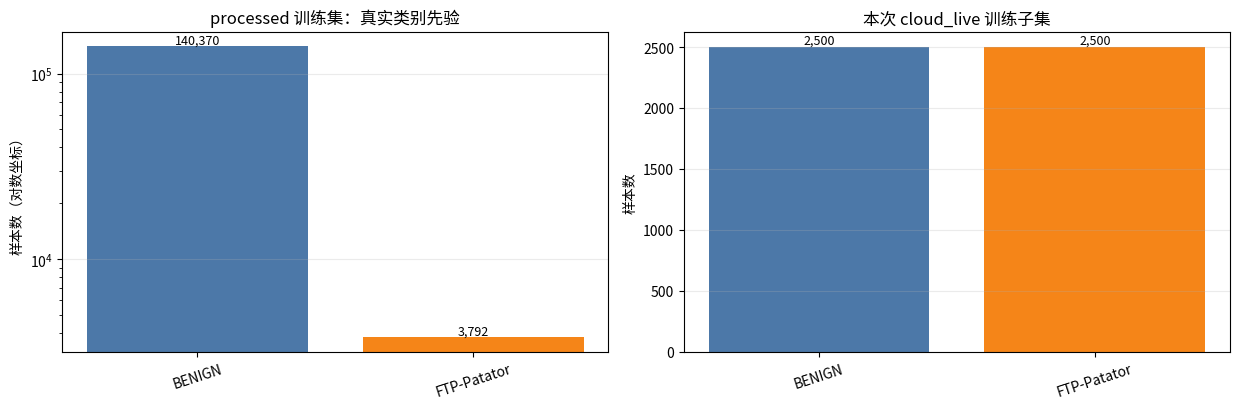

左图保留真实不平衡先验；右图是为了让课堂训练看见各类而构造的均衡子集，不能据此推断部署流量中的攻击发生率。


In [10]:
# 类别统计辅助（原类别原型可视化已精简，此处保留下游所需定义）。
def class_count_frame(y, split_name):
    values, counts = np.unique(y, return_counts=True)
    rows = []
    for cls, count in zip(values, counts):
        rows.append({"split": split_name, "class_id": int(cls), "label": id_to_label.get(int(cls), str(cls)), "count": int(count)})
    return pd.DataFrame(rows)

class_ids = sorted(id_to_label)
class_names = [id_to_label[cls] for cls in class_ids]

def balanced_subset(X, y, per_class=None, replace=False, seed=42, split_name="subset"):
    if per_class is None:
        return np.ascontiguousarray(X, dtype=np.float32), np.ascontiguousarray(y, dtype=np.int32)
    rng = np.random.default_rng(seed)
    selected = []
    shortage_rows = []
    for cls in sorted(np.unique(y).tolist()):
        cls_idx = np.where(y == cls)[0]
        take = int(per_class)
        if len(cls_idx) >= take:
            chosen = rng.choice(cls_idx, size=take, replace=False)
        elif replace:
            chosen = rng.choice(cls_idx, size=take, replace=True)
        else:
            chosen = cls_idx
            shortage_rows.append((int(cls), int(len(cls_idx)), take))
        selected.append(chosen)
    selected = np.concatenate(selected)
    rng.shuffle(selected)
    if shortage_rows:
        details = ", ".join([f"class {cls}: {available}/{requested}" for cls, available, requested in shortage_rows])
        print(f"{split_name} 中部分类别样本少于目标数量，已保留该类全部样本：{details}")
    return np.ascontiguousarray(X[selected], dtype=np.float32), np.ascontiguousarray(y[selected], dtype=np.int32)

train_per_class = SETTINGS["train_per_class"]
eval_per_class = SETTINGS["eval_per_class"]

X_train, y_train = balanced_subset(X_train_full, y_train_full, train_per_class, replace=True, seed=SEED, split_name="train")
X_val, y_val = balanced_subset(X_val_full, y_val_full, eval_per_class, replace=False, seed=SEED + 1, split_name="val")
X_test, y_test = balanced_subset(X_test_full, y_test_full, eval_per_class, replace=False, seed=SEED + 2, split_name="test")

print("=" * 70)
print("本次训练子集：", X_train.shape, y_train.shape)
print("本次验证子集：", X_val.shape, y_val.shape)
print("本次测试子集：", X_test.shape, y_test.shape)
display(pd.concat([
    class_count_frame(y_train, "train_demo"),
    class_count_frame(y_val, "val_demo"),
    class_count_frame(y_test, "test_demo"),
], ignore_index=True))

full_train_counts = np.asarray([(y_train_full == cls).sum() for cls in class_ids])
demo_train_counts = np.asarray([(y_train == cls).sum() for cls in class_ids])
bar_colors = [CLASS_COLORS.get(label, "#9D9DA1") for label in class_names]
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
for ax, counts, title in [
    (axes[0], full_train_counts, "processed 训练集：真实类别先验"),
    (axes[1], demo_train_counts, f"本次 {RUN_PROFILE} 训练子集"),
]:
    bars = ax.bar(class_names, counts, color=bar_colors)
    ax.set_title(title)
    ax.set_ylabel("样本数")
    ax.tick_params(axis="x", rotation=18)
    ax.grid(axis="y", alpha=0.25)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width() / 2, int(count), f"{int(count):,}", ha="center", va="bottom", fontsize=9)
axes[0].set_yscale("log")
axes[0].set_ylabel("样本数（对数坐标）")
plt.tight_layout()
plt.show()
if train_per_class is not None:
    print("左图保留真实不平衡先验；右图是为了让课堂训练看见各类而构造的均衡子集，不能据此推断部署流量中的攻击发生率。")


## 十、构建 MindSpore Dataset

把 numpy 张量封装成 MindSpore `NumpySlicesDataset` 并按 `batch_size` 分批：训练集打乱顺序，验证/测试集保持顺序。后续训练与评估循环通过它按 batch 读取数据。

In [11]:
batch_size = SETTINGS["batch_size"]

train_ds = ds.NumpySlicesDataset(
    data={"data": X_train, "label": y_train},
    shuffle=True,
).batch(batch_size, drop_remainder=False)

val_ds = ds.NumpySlicesDataset(
    data={"data": X_val, "label": y_val},
    shuffle=False,
).batch(batch_size, drop_remainder=False)

test_ds = ds.NumpySlicesDataset(
    data={"data": X_test, "label": y_test},
    shuffle=False,
).batch(batch_size, drop_remainder=False)

one_x, one_y = next(train_ds.create_tuple_iterator(output_numpy=True))
print("batch data:", one_x.shape, one_x.dtype)
print("batch label:", one_y.shape, one_y.dtype)


batch data: (256, 6, 4, 4) float32
batch label: (256,) int32


## 十一、定义多视图 ResNet 检测模型

`TrafficResNet` 先用 `1×1` 卷积把 6 个语义通道融合到 `base_channels` 通道，再经过 3 个不降采样的 `ResidualUnit`（stride=1，空间尺寸保持 `4×4`，通道数 B→B→2B→2B），随后全局平均池化把每个通道的 `4×4` 汇总成一个数，Dropout 抑制过拟合，Dense 输出三类 logits。残差捷径在通道数变化时用 `1×1 Conv+BN` 对齐。

In [12]:
class ResidualUnit(nn.Cell):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, pad_mode="pad", padding=1, has_bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, pad_mode="pad", padding=1, has_bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()
        self.need_proj = in_channels != out_channels
        if self.need_proj:
            self.proj = nn.Conv2d(in_channels, out_channels, kernel_size=1, pad_mode="same", has_bias=False)
            self.proj_bn = nn.BatchNorm2d(out_channels)

    def construct(self, x):
        identity = self.proj_bn(self.proj(x)) if self.need_proj else x
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.bn2(self.conv2(out))
        return self.relu(out + identity)


class TrafficResNet(nn.Cell):
    def __init__(self, in_channels=6, base_channels=32, num_classes=3, dropout=0.2):
        super().__init__()
        self.view_fusion = nn.SequentialCell([
            nn.Conv2d(in_channels, base_channels, kernel_size=1, pad_mode="same", has_bias=False),
            nn.BatchNorm2d(base_channels),
            nn.ReLU(),
        ])
        self.layer1 = ResidualUnit(base_channels, base_channels)
        self.layer2 = ResidualUnit(base_channels, base_channels * 2)
        self.layer3 = ResidualUnit(base_channels * 2, base_channels * 2)
        try:
            self.dropout = nn.Dropout(p=dropout)
        except TypeError:
            self.dropout = nn.Dropout(keep_prob=1.0 - dropout)
        self.head = nn.Dense(base_channels * 2, num_classes)

    def features(self, x):
        x = self.view_fusion(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        return x

    def construct(self, x):
        x = self.features(x)
        x = ops.mean(x, axis=(2, 3))
        x = self.dropout(x)
        return self.head(x)

net = TrafficResNet(
    in_channels=X_train.shape[1],
    base_channels=SETTINGS["base_channels"],
    num_classes=num_classes,
    dropout=0.2,
)
print(net)


TrafficResNet(
  (view_fusion): SequentialCell(
    (0): Conv2d(input_channels=6, output_channels=32, kernel_size=(1, 1), stride=(1, 1), pad_mode=same, padding=0, dilation=(1, 1), group=1, has_bias=False, weight_init=<mindspore.common.initializer.HeUniform object at 0xfffe4ed31f50>, bias_init=None, format=NCHW)
    (1): BatchNorm2d(num_features=32, eps=1e-05, momentum=0.9, gamma=Parameter (name=view_fusion.1.gamma, shape=(32,), dtype=Float32, requires_grad=True), beta=Parameter (name=view_fusion.1.beta, shape=(32,), dtype=Float32, requires_grad=True), moving_mean=Parameter (name=view_fusion.1.moving_mean, shape=(32,), dtype=Float32, requires_grad=False), moving_variance=Parameter (name=view_fusion.1.moving_variance, shape=(32,), dtype=Float32, requires_grad=False))
    (2): ReLU()
  )
  (layer1): ResidualUnit(
    (conv1): Conv2d(input_channels=32, output_channels=32, kernel_size=(3, 3), stride=(1, 1), pad_mode=pad, padding=1, dilation=(1, 1), group=1, has_bias=False, weight_init=<mind

## 十二、训练配置与评估函数

配置交叉熵损失、Adam 优化器（lr=1e-3）和 `TrainOneStepCell` 训练步；定义 `evaluate` 在 eval 模式下统计 loss、accuracy、macro_f1。以验证集 `macro_f1` 作为保存最佳 checkpoint 的依据。

In [13]:
loss_fn = nn.SoftmaxCrossEntropyWithLogits(sparse=True, reduction="mean")
optimizer = nn.Adam(net.trainable_params(), learning_rate=1e-3)
net_with_loss = nn.WithLossCell(net, loss_fn)
train_step = nn.TrainOneStepCell(net_with_loss, optimizer)
train_step.set_train()

def evaluate(dataset):
    net.set_train(False)
    losses = []
    y_true = []
    y_pred = []
    for data, label in dataset.create_tuple_iterator(output_numpy=False):
        logits = net(data)
        loss = loss_fn(logits, label)
        pred = argmax(logits)
        losses.append(float(loss.asnumpy()))
        y_true.append(label.asnumpy().astype(np.int32))
        y_pred.append(pred.asnumpy().astype(np.int32))
    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    return {
        "loss": float(np.mean(losses)) if losses else 0.0,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "macro_f1": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "y_true": y_true,
        "y_pred": y_pred,
    }

epochs = SETTINGS["epochs"]
best_macro_f1 = -1.0
best_ckpt = CKPT_DIR / "experiment03_traffic_resnet_best.ckpt"
checkpoint_saved = False
checkpoint_error = ""
history = []

print("训练轮次：", epochs)
print("batch_size：", batch_size)
print("checkpoint：", best_ckpt)


训练轮次： 8
batch_size： 256
checkpoint： /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/experiment03_traffic_resnet_best.ckpt


## 十三、开始训练 ResNet

逐 epoch 训练：每个 epoch 在训练集上前向反向更新参数，再用 eval 模式单独统计训练/验证指标（避免 Dropout 随机性和 BatchNorm 统计被重复更新）。每轮打印 loss、accuracy、macro_f1 与耗时；当验证 `macro_f1` 提升时把最佳 checkpoint 保存到 `answer/`。

In [14]:
print("=" * 70)
print("开始训练...")

for epoch in range(1, epochs + 1):
    net.set_train(True)
    train_losses = []
    t0 = time.time()

    for data, label in train_ds.create_tuple_iterator(output_numpy=False):
        loss = train_step(data, label)
        train_losses.append(float(loss.asnumpy()))

    # 训练精度使用 eval 模式单独统计，避免 Dropout 随机性和 BatchNorm 统计被重复更新。
    train_metrics = evaluate(train_ds)
    val_metrics = evaluate(val_ds)
    row = {
        "epoch": epoch,
        "train_loss": float(np.mean(train_losses)),
        "train_acc": train_metrics["accuracy"],
        "train_macro_f1": train_metrics["macro_f1"],
        "val_loss": val_metrics["loss"],
        "val_acc": val_metrics["accuracy"],
        "val_macro_f1": val_metrics["macro_f1"],
        "epoch_sec": round(time.time() - t0, 2),
    }
    history.append(row)

    print(
        f"Epoch [{epoch}/{epochs}] "
        f"train_loss={row['train_loss']:.5f} train_acc={row['train_acc']:.4f} "
        f"val_acc={row['val_acc']:.4f} val_macro_f1={row['val_macro_f1']:.4f} "
        f"time={row['epoch_sec']}s"
    )

    if row["val_macro_f1"] > best_macro_f1:
        best_macro_f1 = row["val_macro_f1"]
        try:
            ms.save_checkpoint(net, str(best_ckpt))
            checkpoint_saved = True
            checkpoint_error = ""
            print("  -> saved best checkpoint")
        except Exception as exc:
            checkpoint_saved = False
            checkpoint_error = repr(exc)
            print("  -> checkpoint save failed, using in-memory model:", checkpoint_error)


开始训练...
...Epoch [1/8] train_loss=0.11501 train_acc=0.9774 val_acc=0.9678 val_macro_f1=0.9678 time=38.54s
  -> saved best checkpoint
Epoch [2/8] train_loss=0.01479 train_acc=0.9976 val_acc=0.9956 val_macro_f1=0.9956 time=0.58s
  -> saved best checkpoint
Epoch [3/8] train_loss=0.00952 train_acc=0.9992 val_acc=0.9967 val_macro_f1=0.9967 time=0.58s
  -> saved best checkpoint
Epoch [4/8] train_loss=0.01363 train_acc=0.9966 val_acc=0.9933 val_macro_f1=0.9933 time=0.59s
Epoch [5/8] train_loss=0.00682 train_acc=0.9994 val_acc=0.9967 val_macro_f1=0.9967 time=0.58s
Epoch [6/8] train_loss=0.00531 train_acc=0.9994 val_acc=0.9967 val_macro_f1=0.9967 time=0.57s
Epoch [7/8] train_loss=0.00399 train_acc=0.9994 val_acc=0.9967 val_macro_f1=0.9967 time=0.57s
Epoch [8/8] train_loss=0.00284 train_acc=0.9996 val_acc=0.9967 val_macro_f1=0.9967 time=0.57s


## 十四、测试集评估

加载验证集上表现最好的 checkpoint，在测试集上评估，输出 accuracy、macro_f1、逐类 precision/recall/F1 与混淆矩阵，并把完整结果（含训练历史、指标、混淆矩阵）写入 `answer/traffic_resnet_result.json`。

In [15]:
if best_ckpt.exists():
    param_dict = ms.load_checkpoint(str(best_ckpt))
    ms.load_param_into_net(net, param_dict)

test_metrics = evaluate(test_ds)
y_true = test_metrics.pop("y_true")
y_pred = test_metrics.pop("y_pred")

labels = list(range(num_classes))
target_names = [id_to_label.get(i, str(i)) for i in labels]
cm = confusion_matrix(y_true, y_pred, labels=labels)
report_text = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=target_names,
    digits=4,
    zero_division=0,
)
report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels,
    target_names=target_names,
    digits=4,
    zero_division=0,
    output_dict=True,
)

result = {
    "profile": RUN_PROFILE,
    "device": ACTUAL_DEVICE,
    "data_source": data_source,
    "label_map": id_to_label,
    "test_metrics": test_metrics,
    "confusion_matrix": cm.tolist(),
    "classification_report": report_dict,
    "history": history,
    "checkpoint_saved": checkpoint_saved,
    "checkpoint_path": str(best_ckpt) if checkpoint_saved else "",
    "checkpoint_error": checkpoint_error,
}

result_path = OUTPUT_DIR / "traffic_resnet_result.json"
result_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")

print("=" * 70)
print("测试指标：", test_metrics)
print(report_text)
print("混淆矩阵：")
print(cm)
print("结果已保存：", result_path)


测试指标： {'loss': 0.010520476615056396, 'accuracy': 1.0, 'macro_f1': 1.0}
              precision    recall  f1-score   support

      BENIGN     1.0000    1.0000    1.0000       450
 FTP-Patator     1.0000    1.0000    1.0000       450

    accuracy                         1.0000       900
   macro avg     1.0000    1.0000    1.0000       900
weighted avg     1.0000    1.0000    1.0000       900

混淆矩阵：
[[450   0]
 [  0 450]]
结果已保存： /mnt/workspace/gitCode/cann-learning-hub/contrib/tutorials/ai_security_nuist/01_threat_detect/answer/traffic_resnet_result.json


## 十五、训练曲线与混淆矩阵

绘制训练/验证 loss 曲线、训练 accuracy 与验证 macro_f1 曲线，以及测试集混淆矩阵，用于直观判断是否过拟合、哪些类别容易互相混淆。

,epoch,train_loss,train_acc,train_macro_f1,val_loss,val_acc,val_macro_f1,epoch_sec
0,1,0.115014,0.9774,0.977389,0.146674,0.967778,0.967757,38.54
1,2,0.014785,0.9976,0.997600,0.024070,0.995556,0.995556,0.58
2,3,0.009519,0.9992,0.999200,0.029656,0.996667,0.996667,0.58
3,4,0.013628,0.9966,0.996600,0.042870,0.993333,0.993333,0.59
4,5,0.006815,0.9994,0.999400,0.043650,0.996667,0.996667,0.58
5,6,0.005311,0.9994,0.999400,0.032856,0.996667,0.996667,0.57
6,7,0.003994,0.9994,0.999400,0.025522,0.996667,0.996667,0.57
7,8,0.002845,0.9996,0.999600,0.024280,0.996667,0.996667,0.57


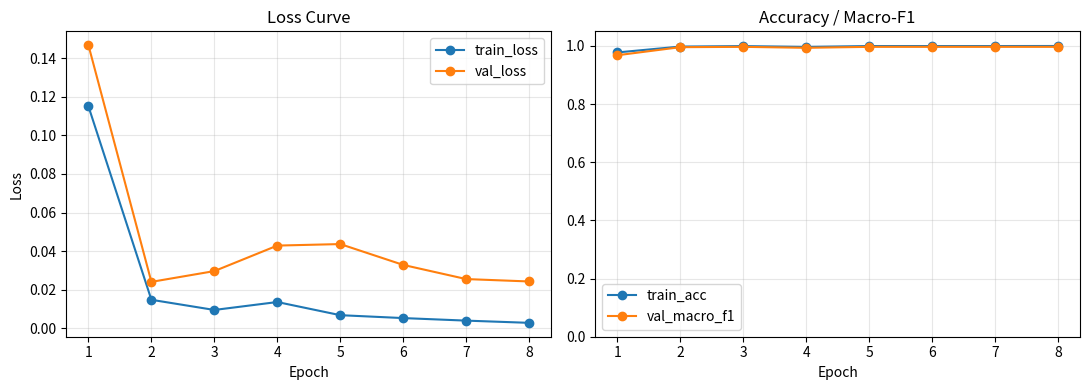

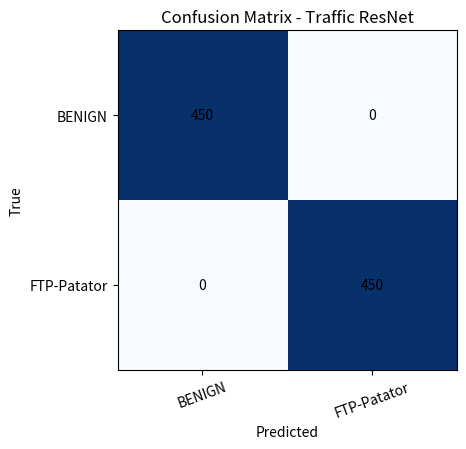

In [16]:
hist_df = pd.DataFrame(history)
display(hist_df)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(hist_df["epoch"], hist_df["train_loss"], marker="o", label="train_loss")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], marker="o", label="val_loss")
axes[0].set_title("Loss Curve")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(hist_df["epoch"], hist_df["train_acc"], marker="o", label="train_acc")
axes[1].plot(hist_df["epoch"], hist_df["val_macro_f1"], marker="o", label="val_macro_f1")
axes[1].set_title("Accuracy / Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].set_ylim(0, 1.05)
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(5.2, 4.6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix - Traffic ResNet")
plt.xticks(range(num_classes), target_names, rotation=20)
plt.yticks(range(num_classes), target_names)
for i in range(num_classes):
    for j in range(num_classes):
        plt.text(j, i, str(cm[i, j]), ha="center", va="center")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()


## 十六、推理性能观察

在测试集上做推理吞吐基准测试（先 warmup 几个 batch，再计时固定数量 batch），输出 `samples_per_second`，并把性能数据追加写入结果文件。该吞吐只反映当前后端与小样本设置，用于解释 CANN/Ascend 推理优化的入口，不应作为跨后端的最终性能结论。

In [17]:
def benchmark_inference(dataset, warmup_batches=2, max_batches=20):
    net.set_train(False)
    seen = 0
    timed_seen = 0
    t0 = None
    for step, (data, label) in enumerate(dataset.create_tuple_iterator(output_numpy=False), 1):
        _ = net(data)
        seen += int(label.shape[0])
        if step == warmup_batches:
            t0 = time.time()
            timed_seen = 0
        elif step > warmup_batches:
            timed_seen += int(label.shape[0])
        if step >= warmup_batches + max_batches:
            break
    elapsed = max(time.time() - t0, 1e-9) if t0 is not None else 0.0
    return {
        "warmup_batches": warmup_batches,
        "timed_samples": timed_seen,
        "elapsed_sec": elapsed,
        "samples_per_second": float(timed_seen / elapsed) if elapsed > 0 else None,
    }

perf = benchmark_inference(test_ds)
print(json.dumps(perf, ensure_ascii=False, indent=2))

result["inference_performance"] = perf
result_path.write_text(json.dumps(result, ensure_ascii=False, indent=2), encoding="utf-8")


{
  "warmup_batches": 2,
  "timed_samples": 388,
  "elapsed_sec": 0.013394832611083984,
  "samples_per_second": 28966.394076394576
}


3539

## 十七、结果解读

- `macro_f1` 比整体准确率更适合观察攻击类，应结合逐类召回率和混淆矩阵判断。
- 均衡子集只服务短时训练，测试结论应回到真实先验下的评估集。
- 默认 profile 适合先跑通链路；正式记录请补充真实分布下的完整训练与校准。

## 结论

已完成从原始流量表格到多通道张量、再到 ResNet 训练评估的完整链路：先把流量表格转为多通道行为表示，TrafficResNet 学习组合统计模式，MindSpore 与 CANN/Ascend 负责训练与高效推理。